In [1]:
import numpy as np
import matplotlib.pyplot as plt

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.io.img_tiles as cimgt

For my model experiment, I am focusing on the Elkhorn Slough in Elkhorn, California, a coastal estuary known for its rich biodiversity and sensitivity to environmental changes. My experiment is designed to simulate the effects of reduced wind speeds on water temperature and dissolved oxygen levels. Using historical meteorological and hydrological data, I will create a computational model that links wind-driven mixing to changes in surface water temperature and oxygen solubility. I anticipate that reduced wind speeds will lead to decreased surface mixing, resulting in higher water temperatures during warm months. Consequently, I expect dissolved oxygen levels to decline due to the combined effects of warmer water and reduced aeration. By projecting these trends over ten years, the model will help assess potential stressors on aquatic life and inform local conservation strategies. Ultimately, this experiment aims to clarify the relationship between wind patterns and estuarine health in the face of climate variability.

## For Rilee's Model (Elkhorn Slough)

#### Question: If average wind speeds are reduced by 50%, how will water temperature and dissolved oxygen (DO) dynamics in Elkhorn Slough evolve over the next decade?

Coordinates: 

Longitude = $121.739^{\circ}$ W - $121.795^{\circ}$ W 

Latitude = $36.80^{\circ}$ N - $36.861^{\circ}$ N 

Grid: 240 rows by 360 columns


In the data file for my model, I will specifiy the following parameters in the `PARM04` namelist in the `data` file:

```
## 
usingSphericalPolarGrid=.TRUE.,
delX=360*0.00015556,
delY=240*0.00025417,
xgOrigin=-121.795,
ygOrigin=36.80,
```

The grid can be recreated in python as follows:

In [2]:
# Define model domain

# These are the OUTER EDGES of the model domain
x_min, x_max = -121.795, -121.739
y_min, y_max = 36.80, 36.861

# Model grid size
nx = 360
ny = 240

# Grid spacing in degrees
delX = (x_max - x_min) / nx
delY = (y_max - y_min) / ny

print("delX:", delX)
print("delY:", delY)
print("Expected nx, ny:", nx, ny)

delX: 0.0001555555555555483
delY: 0.00025416666666666643
Expected nx, ny: 360 240


In [3]:
# Create model grid centers

# Cell centers
rxc = x_min + (np.arange(nx) + 0.5) * delX
ryc = y_min + (np.arange(ny) + 0.5) * delY

# 2D longitude/latitude arrays
rXC, rYC = np.meshgrid(rxc, ryc)

print("rxc shape:", rxc.shape)
print("ryc shape:", ryc.shape)
print("rXC shape:", rXC.shape)
print("rYC shape:", rYC.shape)

assert rxc.shape == (nx,)
assert ryc.shape == (ny,)
assert rXC.shape == (ny, nx)
assert rYC.shape == (ny, nx)

print("Longitude center range:", rXC.min(), "to", rXC.max())
print("Latitude center range:", rYC.min(), "to", rYC.max())

rxc shape: (360,)
ryc shape: (240,)
rXC shape: (240, 360)
rYC shape: (240, 360)
Longitude center range: -121.79492222222223 to -121.73907777777778
Latitude center range: 36.80012708333333 to 36.860872916666665


In [4]:
# Create model grid edges

x_edges = x_min + np.arange(nx + 1) * delX
y_edges = y_min + np.arange(ny + 1) * delY

print("x_edges shape:", x_edges.shape)
print("y_edges shape:", y_edges.shape)

assert x_edges.shape == (nx + 1,)
assert y_edges.shape == (ny + 1,)

print("Longitude edge range:", x_edges[0], "to", x_edges[-1])
print("Latitude edge range:", y_edges[0], "to", y_edges[-1])

x_edges shape: (361,)
y_edges shape: (241,)
Longitude edge range: -121.795 to -121.739
Latitude edge range: 36.8 to 36.861


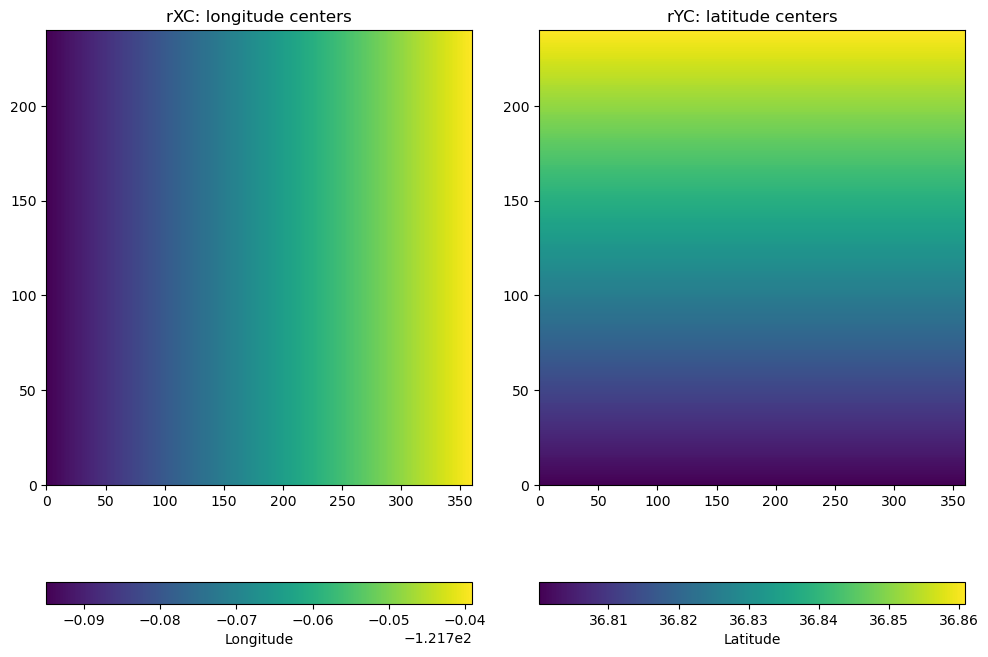

In [5]:
# Plot model longitude and latitude centers

plt.figure(figsize=(10, 7))

plt.subplot(1, 2, 1)
C = plt.pcolormesh(rXC, shading="auto")
plt.colorbar(C, orientation="horizontal", label="Longitude")
plt.title("rXC: longitude centers")

plt.subplot(1, 2, 2)
C = plt.pcolormesh(rYC, shading="auto")
plt.colorbar(C, orientation="horizontal", label="Latitude")
plt.title("rYC: latitude centers")

plt.tight_layout()
plt.show()

### Visualizing the Grid on a Map with Cartopy
To get a sense of where the model is located on the globe, cartopy can be be used to plot the domain on the globe:

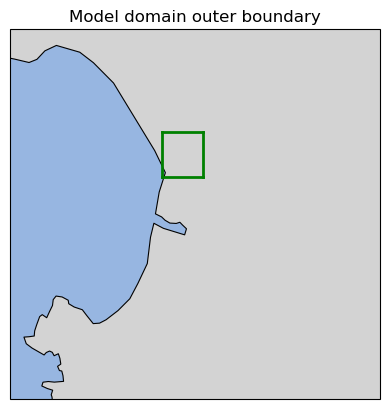

In [6]:
# Plot model domain outline

ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([-122, -121.5, 36.5, 37], crs=ccrs.PlateCarree())

ax.coastlines(resolution="10m", linewidth=0.8)
ax.add_feature(cfeature.LAND, facecolor="lightgrey", zorder=0)
ax.add_feature(cfeature.OCEAN, zorder=0)

# Domain edges
ax.plot([x_min, x_max], [y_min, y_min], "g-", linewidth=2, transform=ccrs.PlateCarree())
ax.plot([x_min, x_max], [y_max, y_max], "g-", linewidth=2, transform=ccrs.PlateCarree())
ax.plot([x_min, x_min], [y_min, y_max], "g-", linewidth=2, transform=ccrs.PlateCarree())
ax.plot([x_max, x_max], [y_min, y_max], "g-", linewidth=2, transform=ccrs.PlateCarree())

plt.title("Model domain outer boundary")
plt.show()

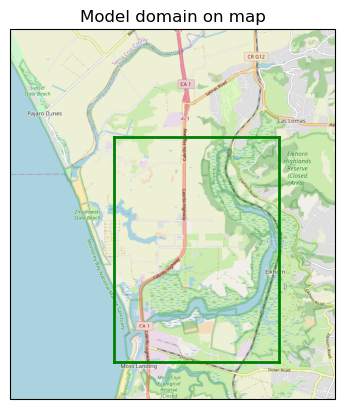

In [7]:
# Plot model domain on OpenStreetMap background

tiler = cimgt.OSM()
ax = plt.axes(projection=tiler.crs)

ax.set_extent([-121.83, -121.72, 36.79, 36.89], crs=ccrs.PlateCarree())
ax.add_image(tiler, 13)

# True domain edges
ax.plot([x_min, x_max], [y_min, y_min], "g-", linewidth=2, transform=ccrs.PlateCarree(), zorder=2)
ax.plot([x_min, x_max], [y_max, y_max], "g-", linewidth=2, transform=ccrs.PlateCarree(), zorder=2)
ax.plot([x_min, x_min], [y_min, y_max], "g-", linewidth=2, transform=ccrs.PlateCarree(), zorder=2)
ax.plot([x_max, x_max], [y_min, y_max], "g-", linewidth=2, transform=ccrs.PlateCarree(), zorder=2)

plt.title("Model domain on map")
plt.show()

### Visualizing the Grid Spacing
The model grid is defined in terms of units in longitude and latitude although it is useful to quantify the grid spacing in terms of more familiar units, such as meters. The following `great_circle_distance` function can be used to quantify this distance:

In [8]:
# Compute grid spacing in meters

def great_circle_distance(lon_ref, lat_ref, Lon, Lat):
    earth_radius = 6371000
    lon_ref_radians = np.radians(lon_ref)
    lat_ref_radians = np.radians(lat_ref)
    lons_radians = np.radians(Lon)
    lats_radians = np.radians(Lat)

    lat_diff = lats_radians - lat_ref_radians
    lon_diff = lons_radians - lon_ref_radians

    d = (
        np.sin(lat_diff * 0.5) ** 2
        + np.cos(lat_ref_radians)
        * np.cos(lats_radians)
        * np.sin(lon_diff * 0.5) ** 2
    )

    h = 2 * earth_radius * np.arcsin(np.sqrt(d))
    return h


dXC = np.zeros((ny, nx - 1))
for row in range(ny):
    for col in range(nx - 1):
        dXC[row, col] = great_circle_distance(
            rXC[row, col], rYC[row, col],
            rXC[row, col + 1], rYC[row, col + 1]
        )

dYC = np.zeros((ny - 1, nx))
for row in range(ny - 1):
    for col in range(nx):
        dYC[row, col] = great_circle_distance(
            rXC[row, col], rYC[row, col],
            rXC[row + 1, col], rYC[row + 1, col]
        )

print("dXC min/max/mean:", dXC.min(), dXC.max(), dXC.mean())
print("dYC min/max/mean:", dYC.min(), dYC.max(), dYC.mean())

dXC min/max/mean: 13.839225379339842 13.850218406788715 13.844723184603795
dYC min/max/mean: 28.262043855011633 28.262043856426278 28.262043855491072


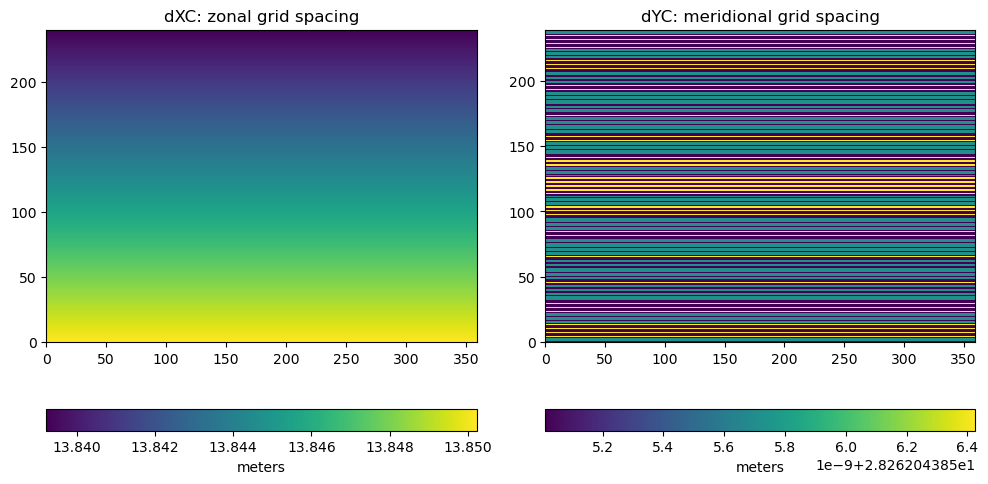

In [9]:
# Plot grid spacing in meters

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
C = plt.pcolormesh(dXC, shading="auto")
plt.colorbar(C, orientation="horizontal", label="meters")
plt.title("dXC: zonal grid spacing")

plt.subplot(1, 2, 2)
C = plt.pcolormesh(dYC, shading="auto")
plt.colorbar(C, orientation="horizontal", label="meters")
plt.title("dYC: meridional grid spacing")

plt.tight_layout()
plt.show()

The meridional grid spacing `dYC` appears striped because matplotlib is color-scaling extremely small floating-point differences. The printed minimum and maximum differ by ~1e-9 m, so the meridional spacing is effectively constant at ~28.26 m.

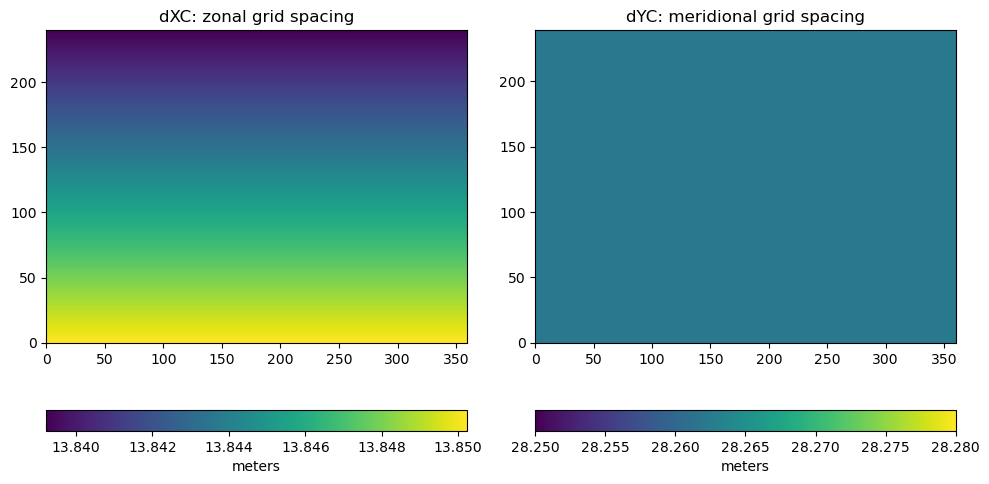

In [10]:
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
C = plt.pcolormesh(dXC, shading="auto")
plt.colorbar(C, orientation="horizontal", label="meters")
plt.title("dXC: zonal grid spacing")

plt.subplot(1, 2, 2)
C = plt.pcolormesh(dYC, shading="auto", vmin=28.25, vmax=28.28)
plt.colorbar(C, orientation="horizontal", label="meters")
plt.title("dYC: meridional grid spacing")

plt.tight_layout()
plt.show()

### Final Grid Summary 

In [11]:
print("Final model grid")
print("----------------")
print(f"Nx = {nx}")
print(f"Ny = {ny}")
print(f"delX = {delX}")
print(f"delY = {delY}")
print(f"xgOrigin = {x_min}")
print(f"ygOrigin = {y_min}")
print(f"rXC shape = {rXC.shape}")
print(f"rYC shape = {rYC.shape}")
print(f"Mean dXC = {dXC.mean():.3f} m")
print(f"Mean dYC = {dYC.mean():.3f} m")

Final model grid
----------------
Nx = 360
Ny = 240
delX = 0.0001555555555555483
delY = 0.00025416666666666643
xgOrigin = -121.795
ygOrigin = 36.8
rXC shape = (240, 360)
rYC shape = (240, 360)
Mean dXC = 13.845 m
Mean dYC = 28.262 m
